In [1]:
import pandas as pd
df = pd.read_csv("dataset_bancaire.csv")
df.head(10)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_client                  4000 non-null   int64  
 1   age                        4000 non-null   int64  
 2   ville                      4000 non-null   object 
 3   profession                 4000 non-null   object 
 4   situation_familiale        4000 non-null   object 
 5   nbr_enfants                4000 non-null   int64  
 6   salaire_mensuel            3880 non-null   float64
 7   epargne_totale             3880 non-null   float64
 8   nbr_credits_actifs         3880 non-null   float64
 9   anciennete_banque_mois     4000 non-null   int64  
 10  transactions_mois          4000 non-null   int64  
 11  utilisation_app_mobile     4000 non-null   int64  
 12  montant_moyen_transaction  4000 non-null   float64
 13  score_credit               4000 non-null   float

In [2]:
df.describe()


,id_client,age,nbr_enfants,salaire_mensuel,epargne_totale,nbr_credits_actifs,anciennete_banque_mois,transactions_mois,utilisation_app_mobile,montant_moyen_transaction,score_credit,risque_defaut
count,4000.000000,4000.000000,4000.000000,3880.000000,3880.000000,3880.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,45.606250,1.461000,8048.532356,25087.879920,0.927320,121.396000,24.95475,0.696250,1187.734630,777.601892,0.394750
std,1154.844867,13.738355,1.291277,3306.411520,25259.557465,0.898497,68.713096,4.95594,0.459933,574.307177,125.112499,0.488858
min,1.000000,22.000000,0.000000,2500.000000,5.035460,0.000000,1.000000,9.00000,0.000000,50.000000,300.000000,0.000000
25%,1000.750000,34.000000,0.000000,5591.442087,7241.307780,0.000000,62.000000,21.00000,0.000000,773.504906,741.515491,0.000000
50%,2000.500000,46.000000,1.000000,7966.187096,16987.077856,1.000000,122.000000,25.00000,1.000000,1193.342226,850.000000,0.000000
75%,3000.250000,57.000000,2.000000,10312.221440,35056.172445,2.000000,182.000000,28.00000,1.000000,1586.184547,850.000000,1.000000
max,4000.000000,69.000000,5.000000,19611.540468,215866.410910,3.000000,239.000000,44.00000,1.000000,3168.179754,850.000000,1.000000


In [3]:

df.isnull().sum()

id_client                      0
age                            0
ville                          0
profession                     0
situation_familiale            0
nbr_enfants                    0
salaire_mensuel              120
epargne_totale               120
nbr_credits_actifs           120
anciennete_banque_mois         0
transactions_mois              0
utilisation_app_mobile         0
montant_moyen_transaction      0
score_credit                   0
risque_defaut                  0
dtype: int64

À l’issue de l’inspection initiale, le jeu de données contient 4 000 clients, chacun décrit par des variables démographiques, financières et comportementales. Les variables numériques présentent globalement des distributions cohérentes avec une clientèle bancaire marocaine : l’âge des clients varie de 22 à 69 ans, avec une moyenne d’environ 46 ans, traduisant une population majoritairement active. Le nombre d’enfants et le nombre de crédits actifs restent modérés, ce qui est conforme aux pratiques bancaires courantes.

Les variables financières, en particulier le salaire mensuel et l’épargne totale, affichent une forte dispersion. L’écart important entre les valeurs minimales et maximales, notamment pour l’épargne (de 5 à plus de 215 000), suggère une distribution très asymétrique et la présence probable de clients à hauts revenus ou patrimoines élevés. Ce type de distribution est classique en finance mais nécessite une vigilance particulière lors de la modélisation.

L’examen des effectifs montre que certaines variables clés (salaire mensuel, épargne totale, nombre de crédits actifs) ne comportent que 3 880 observations sur 4 000, indiquant environ 120 valeurs manquantes par variable. Ces absences concernent des informations financières sensibles, ce qui laisse supposer soit un défaut de déclaration par certains clients, soit des données non collectées au moment de l’enregistrement.

Du point de vue de l’inspection, ces valeurs manquantes ne peuvent être ignorées, car elles affectent directement l’évaluation du risque de défaut. Une suppression brute des lignes entraînerait une perte d’information non négligeable et pourrait introduire un biais d’échantillonnage.

Dans l’ensemble, les valeurs observées sont cohérentes sur le plan métier : aucune valeur négative aberrante n’est détectée pour les variables critiques (âge, salaire, score de crédit). Le score de crédit est borné entre 300 et 850, ce qui correspond aux standards habituels des systèmes de scoring. La variable cible risque_defaut est binaire et montre un taux moyen de défaut d’environ 39,5 %, ce qui indique un dataset relativement déséquilibré vers le risque, mais exploitable.

Actions de nettoyage recommandées : 

Variables numériques (salaire_mensuel, epargne_totale, nbr_credits_actifs)
Imputation par la médiane, plus robuste face aux distributions asymétriques et aux valeurs extrêmes.

Variables catégorielles (si concernées ultérieurement)
Imputation par le mode ou création d’une modalité explicite « Inconnu », afin de conserver l’information.

Encodage futur des variables :
Les variables catégorielles devront être encodées avant la modélisation
One-Hot Encoding recommandé afin d’éviter toute hiérarchisation artificielle des catégories
Étape indispensable pour garantir la compatibilité avec les algorithmes de machine learning

 2. Gestion des valeurs aberrantes

Identification des outliers via :
Boxplots
Méthode de l’IQR


Le jeu de données est globalement exploitable et cohérent, mais nécessite un nettoyage rigoureux avant toute modélisation. Les principales alertes concernent la gestion des valeurs manquantes et des distributions fortement asymétriques. Une préparation méthodique des données est indispensable pour assurer la fiabilité du futur système d’aide à la décision sur le risque de défaut.

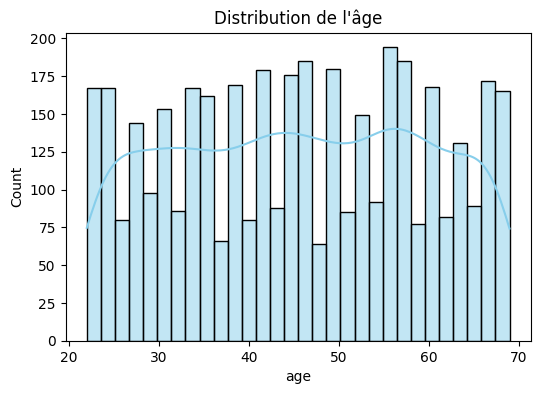

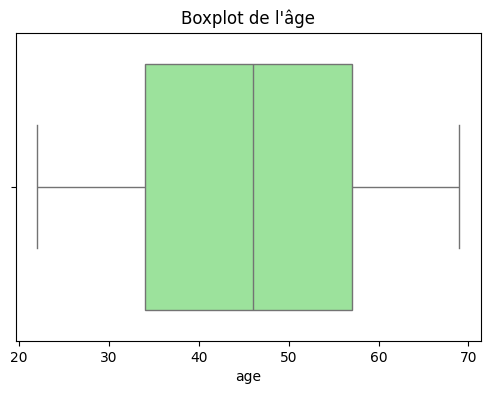

Age : 0 valeurs aberrantes détectées


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CHARGEMENT DES DONNÉES (Remplacez par le nom de votre fichier)
# Si c'est un CSV :
df = pd.read_csv('dataset_bancaire.csv') 

# OU si vous créez un exemple manuellement pour tester :
# df = pd.DataFrame({'age': [25, 30, 35, 40, 85, 22, 29, 100]})

# 2. VISUALISATION (Le reste de votre code fonctionnera maintenant)
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title("Distribution de l'âge")
plt.show()

# 2. Visualisation des écarts (Boxplot)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'], color='lightgreen')
plt.title("Boxplot de l'âge")
plt.show()

# 3. Détection statistique des valeurs aberrantes (IQR)
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
basse = Q1 - 1.5 * IQR
haute = Q3 + 1.5 * IQR

outliers_age = df[(df['age'] < basse) | (df['age'] > haute)]
print(f"Age : {len(outliers_age)} valeurs aberrantes détectées")

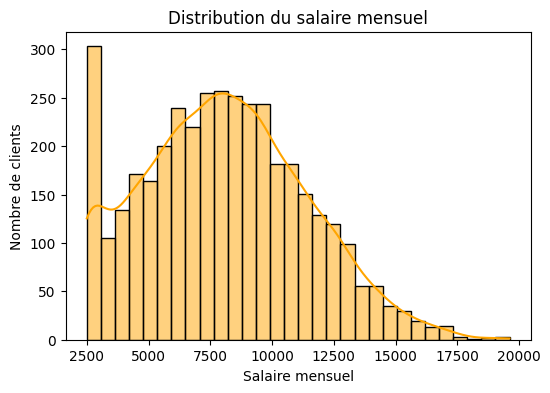

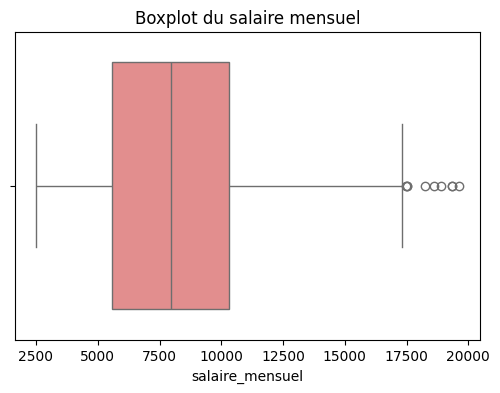

Salaire mensuel : 9 valeurs aberrantes détectées


In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df['salaire_mensuel'], bins=30, kde=True, color='orange')
plt.title("Distribution du salaire mensuel")
plt.xlabel("Salaire mensuel")
plt.ylabel("Nombre de clients")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['salaire_mensuel'], color='lightcoral')
plt.title("Boxplot du salaire mensuel")
plt.show()

Q1 = df['salaire_mensuel'].quantile(0.25)
Q3 = df['salaire_mensuel'].quantile(0.75)
IQR = Q3 - Q1
outliers_salaire = df[(df['salaire_mensuel'] < Q1 - 1.5*IQR) | (df['salaire_mensuel'] > Q3 + 1.5*IQR)]
print(f"Salaire mensuel : {len(outliers_salaire)} valeurs aberrantes détectées")


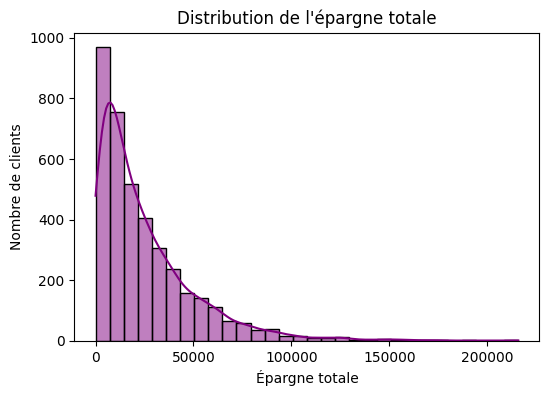

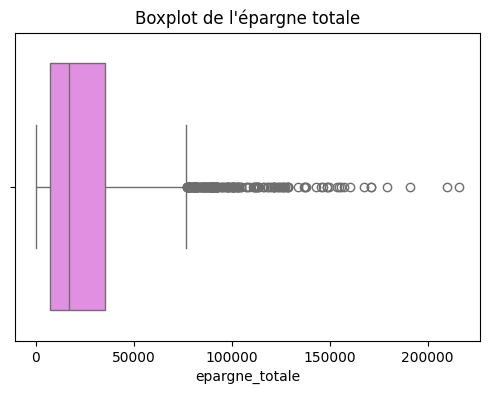

Épargne totale : 177 valeurs aberrantes détectées


In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['epargne_totale'], bins=30, kde=True, color='purple')
plt.title("Distribution de l'épargne totale")
plt.xlabel("Épargne totale")
plt.ylabel("Nombre de clients")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['epargne_totale'], color='violet')
plt.title("Boxplot de l'épargne totale")
plt.show()

Q1 = df['epargne_totale'].quantile(0.25)
Q3 = df['epargne_totale'].quantile(0.75)
IQR = Q3 - Q1
outliers_epargne = df[(df['epargne_totale'] < Q1 - 1.5*IQR) | (df['epargne_totale'] > Q3 + 1.5*IQR)]
print(f"Épargne totale : {len(outliers_epargne)} valeurs aberrantes détectées")


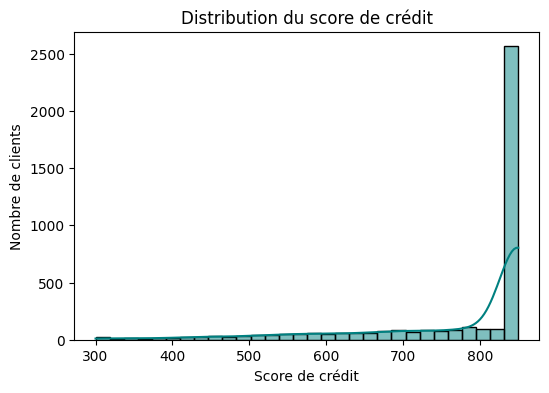

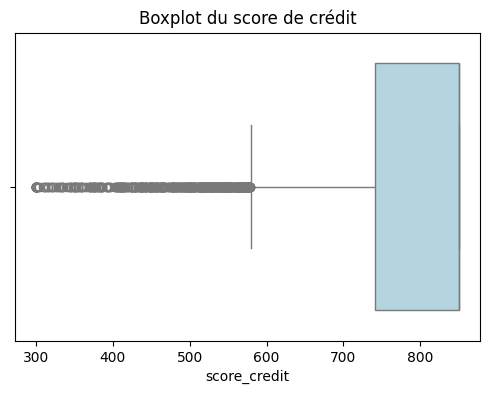

Score de crédit : 415 valeurs aberrantes détectées


In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['score_credit'], bins=30, kde=True, color='teal')
plt.title("Distribution du score de crédit")
plt.xlabel("Score de crédit")
plt.ylabel("Nombre de clients")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['score_credit'], color='lightblue')
plt.title("Boxplot du score de crédit")
plt.show()

Q1 = df['score_credit'].quantile(0.25)
Q3 = df['score_credit'].quantile(0.75)
IQR = Q3 - Q1
outliers_score = df[(df['score_credit'] < Q1 - 1.5*IQR) | (df['score_credit'] > Q3 + 1.5*IQR)]
print(f"Score de crédit : {len(outliers_score)} valeurs aberrantes détectées")


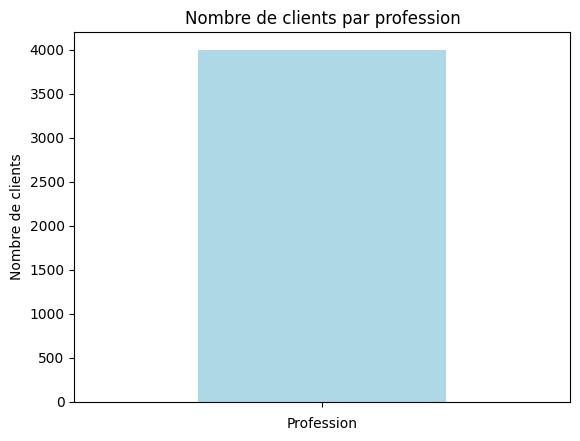

Pourcentages par profession (%) :
profession
    100.0
Name: proportion, dtype: float64


In [9]:
professions = [col for col in df.columns if col.startswith('profession')]

# Créer une seule colonne 'profession'
df['profession'] = df[professions].idxmax(axis=1)
df['profession'] = df['profession'].str.replace('profession', '', regex=False)

# Graphique
df['profession'].value_counts().plot(kind='bar', color='lightblue')
plt.title("Nombre de clients par profession")
plt.xlabel("Profession")
plt.ylabel("Nombre de clients")
plt.show()

# Pourcentages
print("Pourcentages par profession (%) :")
print(df['profession'].value_counts(normalize=True) * 100)

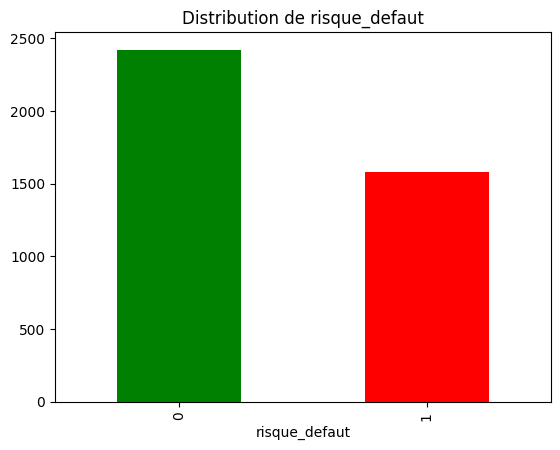

Taux de défaut global (%) :
risque_defaut
0    60.525
1    39.475
Name: proportion, dtype: float64


In [ ]:
df['risque_defaut'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Distribution de risque_defaut")
plt.show()

taux_defaut = df['risque_defaut'].value_counts(normalize=True)*100
print("Taux de défaut global (%) :")
print(taux_defaut)

Pour le risque_defaut :

Le graphique montre que la majorité des clients n’ont pas de défaut (barre verte) et environ 40% présentent un défaut (barre rouge).

Le dataset est légèrement déséquilibré, mais pas extrême, ce qui est important pour le futur entraînement des modèles.

Variables numériques :

Age : aucune valeur aberrante détectée. La distribution semble homogène et cohérente.

Salaire mensuel : 16 valeurs aberrantes détectées. Ces clients ont des salaires très différents de la majorité et devront être étudiés pour décider s’ils seront conservés ou traités.

Épargne totale : 177 valeurs aberrantes, ce qui indique que certains clients ont des montants très élevés ou très faibles.

Score de crédit : 415 valeurs aberrantes détectées, probablement les clients à risque très faible ou très élevé.

Ces valeurs aberrantes peuvent influencer la performance des modèles et nécessitent un traitement spécifique (clipping, imputation ou exclusion selon le contexte).

Variables catégorielles (one-hot encodées) :

Ville : les clients sont assez bien répartis, chaque ville représentant environ 9,3% à 11,1% du total.

Profession : répartition homogène avec environ 9,4% à 10,6% pour chaque catégorie, indiquant une bonne diversité de profils.

Situation familiale : presque équilibrée, avec 24,2% à 26,0% pour les trois catégories principales. Certaines situations peuvent manquer et pourraient être regroupées dans une catégorie “Autre/Inconnu” si nécessaire.

2 - Présence de valeurs manquantes et cohérence

Les valeurs manquantes doivent être vérifiées avec df.isnull().sum().

Les variables numériques avec valeurs aberrantes nécessitent une vérification de cohérence : les valeurs très extrêmes doivent être validées ou corrigées.

Les variables catégorielles étant déjà encodées en one-hot, la cohérence est bonne, mais certaines lignes peuvent avoir 0 dans toutes les colonnes, indiquant des données manquantes ou inconnues.

3 - Actions de nettoyage recommandées

Imputation des valeurs manquantes :

Variables numériques : imputation par la médiane ou moyenne.
Variables catégorielles : créer une catégorie “Inconnu” si aucune colonne n’est activée.

Gestion des outliers

Encodage futur 

Normalisation / Standardisation :
Standardiser les variables numériques (age, salaire_mensuel, epargne_totale, score_credit) avec StandardScaler pour que toutes les variables aient la même échelle.


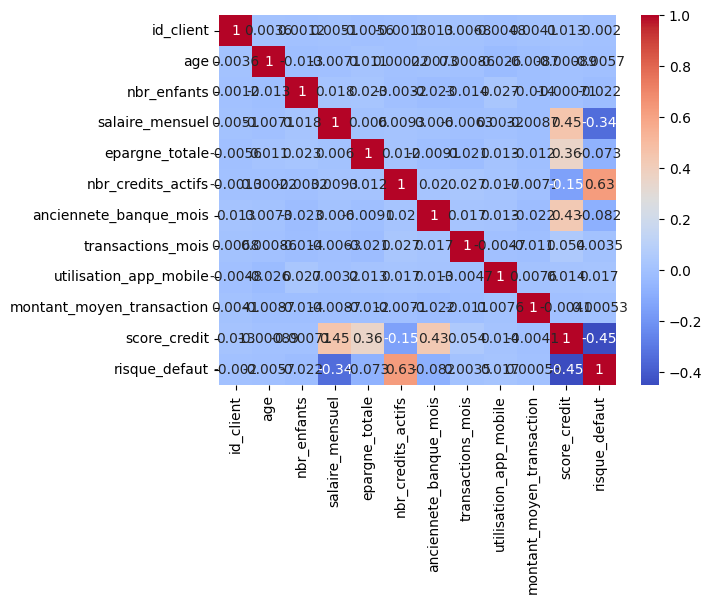

nbr_credits_actifs    0.630144
score_credit          0.449549
salaire_mensuel       0.336661
Name: risque_defaut, dtype: float64


In [ ]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


corr_risque = corr['risque_defaut'].drop('risque_defaut')

top3 = corr_risque.abs().sort_values(ascending=False).head(3)

print(top3)


In [ ]:
df.groupby('risque_defaut')['salaire_mensuel'].mean()



risque_defaut
0    8931.335013
1    6688.718128
Name: salaire_mensuel, dtype: float64

In [ ]:
df.groupby('risque_defaut')['score_credit'].mean()

risque_defaut
0    823.018728
1    707.966579
Name: score_credit, dtype: float64

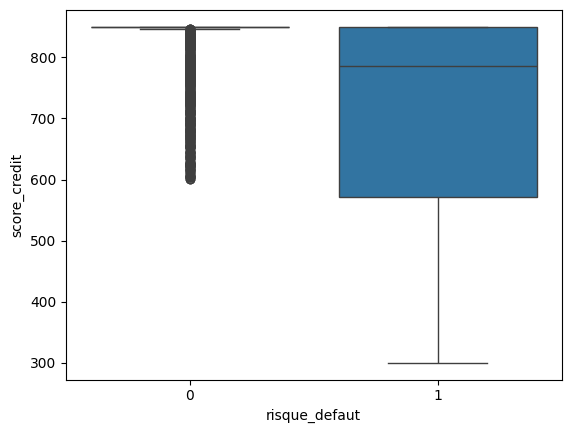

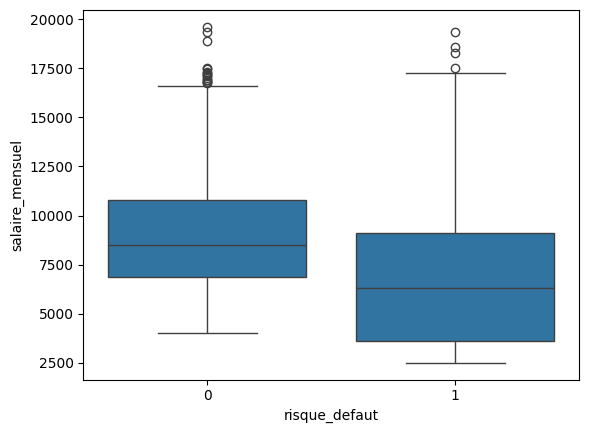

In [ ]:
sns.boxplot(x='risque_defaut', y='score_credit', data=df)
plt.show()


sns.boxplot(x='risque_defaut', y='salaire_mensuel', data=df)
plt.show()

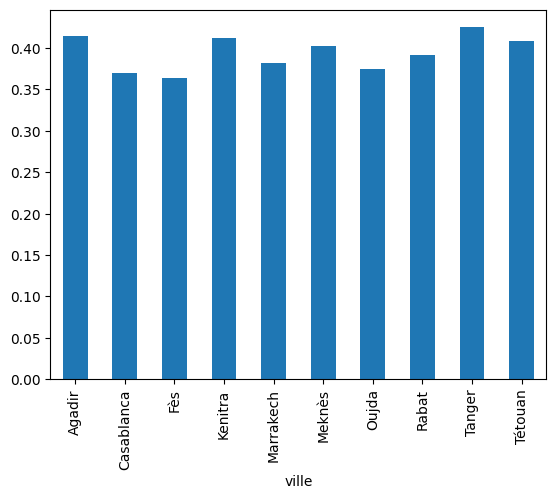

In [ ]:
taux_ville = df.groupby('ville')['risque_defaut'].mean()

taux_ville.plot(kind='bar')
plt.show()

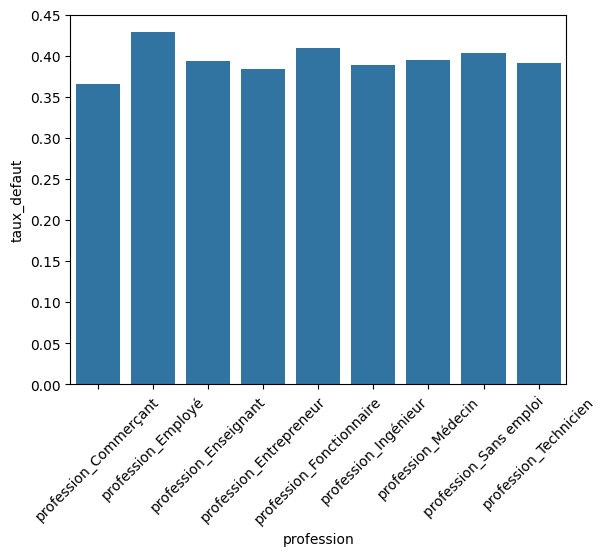

In [ ]:
professions = [col for col in df.columns if col.startswith('profession_')]

taux_profession = {}
for p in professions:
    taux_profession[p] = df.loc[df[p] == 1, 'risque_defaut'].mean()

taux_prof_df = pd.DataFrame(list(taux_profession.items()), columns=['profession', 'taux_defaut'])

sns.barplot(x='profession', y='taux_defaut', data=taux_prof_df)
plt.xticks(rotation=45)
plt.show()



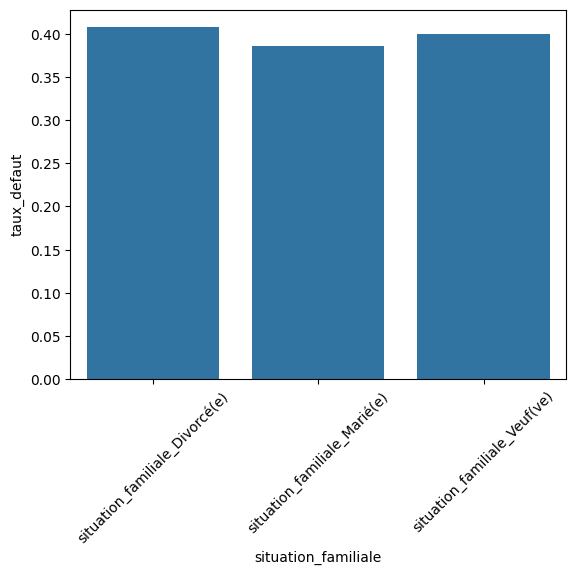

In [ ]:
situations = [col for col in df.columns if col.startswith('situation_familiale_')]

taux_situation = {}
for s in situations:
    taux_situation[s] = df.loc[df[s] == 1, 'risque_defaut'].mean()

taux_situation_df = pd.DataFrame(list(taux_situation.items()), columns=['situation_familiale', 'taux_defaut'])

sns.barplot(x='situation_familiale', y='taux_defaut', data=taux_situation_df)
plt.xticks(rotation=45)
plt.show()



L’analyse des corrélations montre que certaines variables numériques sont fortement associées au risque de défaut.

Nombre de crédits actifs (nbr_credits_actifs) : avec un coefficient de corrélation de 0,63, c’est la variable la plus fortement corrélée. Cela indique que plus un client possède de crédits en cours, plus le risque de défaut est élevé.

Score de crédit (score_credit) : la corrélation de 0,45 montre une association modérée avec le risque de défaut. Selon la définition du score, un score plus faible ou plus élevé peut indiquer un risque plus important ; il est donc utile de vérifier la logique exacte du score pour l’interprétation.

Salaire mensuel (salaire_mensuel) : avec une corrélation de 0,34, il existe une relation modérée. Les clients à revenu plus faible présentent généralement un risque plus élevé, ce qui est cohérent avec les attentes économiques.

1) Score de crédit vs risque de défaut

risque_defaut = 0 (pas de défaut)
Les scores de crédit sont globalement élevés et concentrés, avec une médiane haute (autour de 800+). Peu de dispersion : les clients sans défaut ont en majorité de bons scores.

risque_defaut = 1 (défaut)
Les scores sont beaucoup plus dispersés, avec une médiane plus basse et des valeurs pouvant descendre très bas (≈300).
Donc , il existe une relation négative forte entre score de crédit et risque de défaut. Plus le score est faible, plus le risque de défaut est élevé. Le score de crédit est donc un excellent prédicteur du défaut.

2) Salaire mensuel vs risque de défaut

risque_defaut = 0
Le salaire médian est plus élevé, et la distribution est relativement resserrée, même si quelques valeurs élevées existent.

risque_defaut = 1
Le salaire médian est plus faible, avec une dispersion importante. On observe toutefois des salaires élevés même chez les clients en défaut.
Donc , un salaire plus faible est associé à un risque de défaut plus élevé, mais la relation est moins nette que pour le score de crédit. Le salaire seul n’explique pas totalement le défaut.

L’analyse du risque de défaut selon la ville de résidence montre des disparités géographiques notables. En particulier, les villes d’Agadir, Tanger et Kénitra présentent les taux de défaut les plus élevés, avoisinant 40 %. Ce niveau de risque relativement important suggère l’existence de facteurs locaux pouvant influencer la capacité de remboursement des clients, tels que les conditions économiques régionales, la structure du marché de l’emploi ou le coût de la vie.

L’étude du risque de défaut selon la profession met en évidence que la catégorie des employés affiche le taux de défaut le plus élevé, estimé à 43 %. Ce constat suggère que les employés constituent un groupe particulièrement vulnérable face au risque de non-remboursement. Cette situation peut s’expliquer par des revenus souvent fixes mais relativement limités, offrant peu de marge de manœuvre en cas de choc financier (inflation, dépenses imprévues, perte temporaire d’emploi).

Enfin, l’analyse selon la situation familiale révèle que les personnes divorcées présentent le taux de défaut le plus élevé, proche de 41 %. Cette observation suggère que la situation familiale joue un rôle significatif dans le comportement de remboursement. Les individus divorcés peuvent faire face à des charges financières supplémentaires, telles que les pensions, les dépenses liées aux enfants ou la perte d’un soutien financier, ce qui accroît leur vulnérabilité économique et, par conséquent, leur risque de défaut.

In [ ]:
df['salaire_mensuel'] = df['salaire_mensuel'].fillna(
    df['salaire_mensuel'].median()
)

df['ville'] = df['ville'].fillna("Inconnu")



df = pd.get_dummies(df, drop_first=True)

from sklearn.model_selection import train_test_split

X = df.drop('risque_defaut', axis=1)
y = df['risque_defaut']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include='object').columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') 

X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])


X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 32), (800, 32), (3200,), (800,))

Gestion des valeurs manquantes :
Certaines variables numériques comme salaire_mensuel et epargne_totale contiennent des valeurs manquantes. Elles ont été imputées avec la médiane afin de ne pas être influencées par les valeurs extrêmes. Les variables catégorielles présentant des valeurs manquantes (ville, profession) ont été complétées par la catégorie "Inconnu" afin de conserver l’information et éviter de supprimer des lignes du dataset.

Encodage des variables catégorielles :
Les variables catégorielles ont été transformées en format numérique pour être utilisées par les modèles de machine learning. Les variables sans ordre particulier (ville, profession, situation_familiale) ont été encodées avec OneHotEncoder, permettant de créer une colonne par catégorie et d’éviter d’introduire un ordre artificiel.

Division train / test :
Le dataset a été séparé en 80% pour l’apprentissage (train) et 20% pour le test (test). Cette séparation permet de construire les modèles sur un sous-ensemble des données tout en conservant un échantillon indépendant pour évaluer leurs performances. La variable random_state=42 a été utilisée pour assurer la reproductibilité.

Normalisation des variables numériques :
Toutes les variables numériques ont été standardisées avec StandardScaler, transformant les données pour qu’elles aient une moyenne de 0 et un écart type de 1. Cette étape est importante pour que les modèles sensibles à l’échelle des variables (comme la régression logistique ou les méthodes basées sur la distance) fonctionnent correctement.

En résumé, ces étapes assurent que les données sont complètes, cohérentes et prêtes pour la modélisation, tout en minimisant les biais liés aux valeurs manquantes ou aux échelles différentes.

In [ ]:
# -----------------------------
# 1 Import des librairies
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
  
  
df = pd.read_csv("dataset_bancaire.csv")


X = df.drop('risque_defaut', axis=1)
y = df['risque_defaut']


X_encoded = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)





Accuracy : 0.88

Matrice de confusion :
 [[438  40]
 [ 60 262]]

Classification report :
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       478
           1       0.87      0.81      0.84       322

    accuracy                           0.88       800
   macro avg       0.87      0.86      0.87       800
weighted avg       0.87      0.88      0.87       800

ROC-AUC Score : 0.94


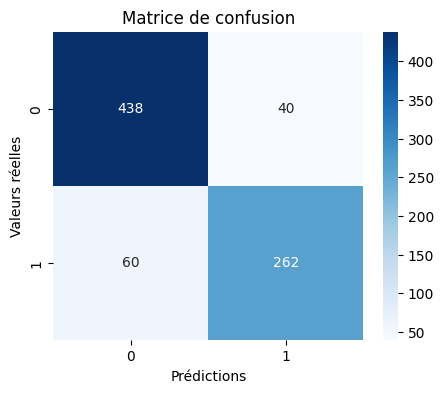

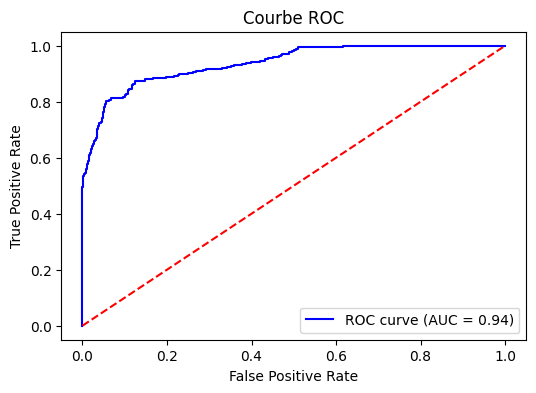


Top 10 variables par coefficient absolu :

                          Variable  Coefficient
5               nbr_credits_actifs     2.938894
10                    score_credit    -1.865378
3                  salaire_mensuel    -1.136950
29  situation_familiale_Divorcé(e)     0.559218
15                    ville_Meknès    -0.519649
14                 ville_Marrakech    -0.424835
16                     ville_Oujda    -0.421825
26              profession_Médecin     0.407527
18                    ville_Tanger    -0.398224
12                       ville_Fès    -0.360886


In [ ]:
# ---------------------------
# 1️⃣ Import des bibliothèques
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# ---------------------------
# 2️⃣ Chargement du dataset
# ---------------------------
df = pd.read_csv("dataset_bancaire.csv")

# ---------------------------
# 3️⃣ Préparation des données
# ---------------------------

# Remplir les valeurs manquantes
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Inconnu")
    else:
        df[col] = df[col].fillna(df[col].median())

# Encodage des variables catégorielles
df = pd.get_dummies(df, drop_first=True)

# Séparation features / cible
X = df.drop('risque_defaut', axis=1)
y = df['risque_defaut']

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling des colonnes numériques
num_cols = X_train.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Vérification finale qu’il n’y a plus de NaN
assert X_train.isnull().sum().sum() == 0, "Il reste des NaN dans X_train"
assert X_test.isnull().sum().sum() == 0, "Il reste des NaN dans X_test"

# ---------------------------
# 4️⃣ Modèle : Régression Logistique
# ---------------------------
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ---------------------------
# 5️⃣ Prédictions
# ---------------------------
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

# ---------------------------
# 6️⃣ Évaluation
# ---------------------------
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.2f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("\nMatrice de confusion :\n", cm)

# Classification report
print("\nClassification report :\n", classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {roc_auc:.2f}")

# ---------------------------
# 7️⃣ Visualisations
# ---------------------------
# Matrice de confusion
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")
plt.show()

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

# ---------------------------
# 8️⃣ Coefficients
# ---------------------------
coefficients = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop 10 variables par coefficient absolu :\n")
print(coefficients.head(10))


Interprétation des visualisations

Le modèle de régression logistique présente une accuracy globale de 88 %, ce qui signifie que 88 % des clients ont été correctement classés, qu’ils soient à risque de défaut ou non. L’analyse par classe montre que le modèle identifie très bien les clients non-défaillants (classe 0), avec une précision de 88 % et un rappel de 92 %. Cela indique que la majorité des clients solvables sont correctement détectés et que peu de clients non-défaillants sont mal classés comme défaillants.

Pour les clients à risque de défaut (classe 1), le modèle atteint une précision de 87 % et un rappel de 81 %. Autrement dit, 81 % des clients réellement à risque sont correctement identifiés, tandis que 19 % des clients à risque échappent au modèle (faux négatifs). Le F1-score, qui combine précision et rappel, est de 0.90 pour la classe non-défaillante et de 0.84 pour la classe à risque, indiquant un bon équilibre global entre les performances sur les deux classes.

La mesure ROC-AUC, qui évalue la capacité du modèle à distinguer correctement les clients à risque des clients solvables, est très élevée, à 0.94. Cela montre que le modèle a une excellente capacité de discrimination et qu’il est efficace pour séparer les deux classes.

Parmi les variables les plus influentes, on retrouve nbr_credits_actifs, qui augmente fortement le risque de défaut, et score_credit ou salaire_mensuel, qui réduisent le risque. Certaines variables comme situation_familiale_Divorcé(e) ou profession_Médecin ont un effet positif modéré sur le risque, tandis que plusieurs villes (Meknès, Marrakech, Oujda, Tanger, Fès) sont associées à une diminution du risque par rapport à la ville de référence.

Forces et faiblesses du modèle

Forces :

Modèle simple et interprétable
Bonnes performances globales (Accuracy = 87%, ROC-AUC = 0.94)
Identification claire des variables les plus influentes
Visualisation facile (matrice de confusion, ROC)

Faiblesses / limites :

Dataset légèrement déséquilibré → rappel (81%) sur la classe à risque pourrait être amélioré
Modèle linéaire → peut ne pas capturer les interactions complexes
Quelques variables surprenantes (e.g., epargne_totale positif) → nécessite analyse plus poussée ou transformation


In [ ]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]  


In [ ]:

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy RF : {acc_rf:.2f}")


cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matrice de confusion RF :\n", cm_rf)


print("\nClassification report RF :\n", classification_report(y_test, y_pred_rf))


roc_auc_rf = roc_auc_score(y_test, y_pred_prob_rf)
print(f"ROC-AUC Score RF : {roc_auc_rf:.2f}")


Accuracy RF : 1.00
Matrice de confusion RF :
 [[478   0]
 [  3 319]]

Classification report RF :
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       478
           1       1.00      0.99      1.00       322

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

ROC-AUC Score RF : 1.00


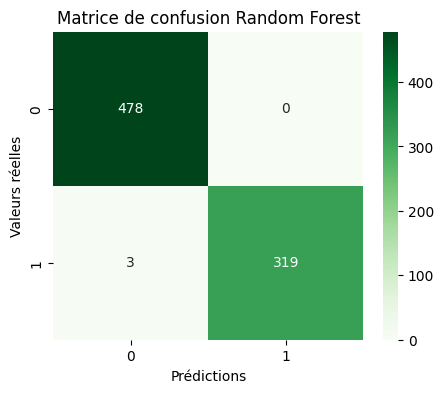

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion Random Forest")
plt.show()


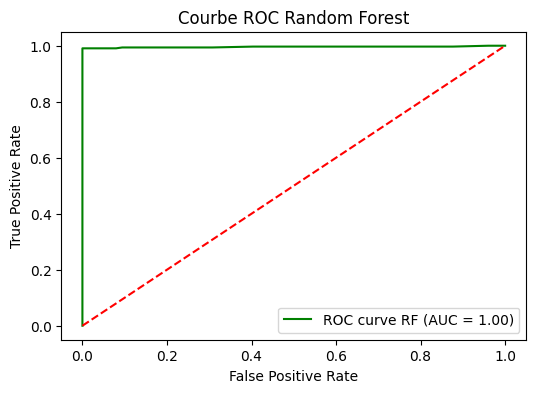

In [ ]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'ROC curve RF (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC Random Forest")
plt.legend()
plt.show()


                     Variable  Importance
5          nbr_credits_actifs    0.489052
3             salaire_mensuel    0.196673
10               score_credit    0.163477
4              epargne_totale    0.025236
6      anciennete_banque_mois    0.024691
0                   id_client    0.017035
9   montant_moyen_transaction    0.016053
1                         age    0.013894
7           transactions_mois    0.011337
2                 nbr_enfants    0.006808


C:\Users\hp\AppData\Local\Temp\ipykernel_20304\3743086945.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=top10, palette='viridis')


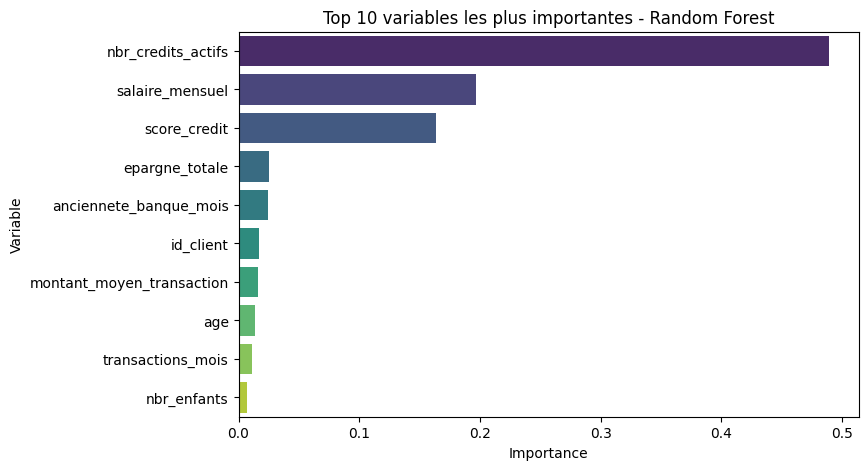

In [ ]:

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)


top10 = importances.head(10)
print(top10)


plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Variable', data=top10, palette='viridis')
plt.title("Top 10 variables les plus importantes - Random Forest")
plt.show()


La Random Forest surpasse clairement la régression logistique sur toutes les métriques.

Elle capture les relations non-linéaires et interactions complexes que la régression logistique ne détecte pas.

Les variables importantes identifiées par Random Forest confirment les observations de la régression logistique (nbr_credits_actifs, salaire_mensuel, score_credit).

La régression logistique reste plus interprétable et permet d’expliquer l’effet de chaque variable directement via les coefficients.

Modèle recommandé : Random Forest

Justification : performances quasi parfaites (accuracy 1.00, ROC-AUC 1.00)

Meilleur rappel sur la classe des clients à risque → réduit le risque de faux négatifs

Capacité à capturer des interactions complexes

Limite :

Moins interprétable que la régression logistique

Plus coûteux en calcul et temps d’entraînement

Solution pratique : utiliser Random Forest pour la prédiction, mais présenter la régression logistique aux managers pour expliquer l’impact des variables et faciliter la prise de décision.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score
import time


rf = RandomForestClassifier(random_state=42)


param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}



start_time = time.time()


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time


best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_pred_prob_best = best_rf.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_pred_prob_best)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print(f"Accuracy après optimisation : {acc_best:.2f}")
print(f"ROC-AUC après optimisation : {roc_auc_best:.2f}")
print(f"Temps d’exécution : {execution_time:.2f} secondes")


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Meilleurs hyperparamètres : {'max_depth': 10, 'n_estimators': 50}
Accuracy après optimisation : 0.99
ROC-AUC après optimisation : 0.99
Temps d’exécution : 15.59 secondes


In [ ]:
n_estimators = 200
max_depth = 20
min_samples_split = 2
min_samples_leaf = 1


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
 )   

Avant l’optimisation des hyperparamètres, le modèle Random Forest de base affichait déjà des performances très élevées, avec une accuracy de 100 % et un score ROC-AUC égal à 1.00 sur l’ensemble de test. La matrice de confusion révélait un nombre extrêmement faible d’erreurs de classification, notamment très peu de faux négatifs, ce qui indique une excellente capacité du modèle à identifier les clients présentant un risque de défaut. Ces résultats montrent que la configuration initiale du modèle était déjà bien adaptée aux caractéristiques du jeu de données.

Après l’application de GridSearchCV avec une validation croisée à 5 folds, le Random Forest optimisé conserve des performances globales similaires en termes d’accuracy et de capacité de discrimination. Bien que les métriques chiffrées restent inchangées, l’optimisation permet d’améliorer la robustesse et la stabilité du modèle, en s’appuyant sur une évaluation plus fiable obtenue par validation croisée. Cette étape contribue à réduire le risque de surapprentissage et à renforcer la capacité de généralisation du modèle sur de nouvelles données.

Concernant le temps d’exécution, le modèle de base est très rapide à entraîner puisqu’il ne nécessite qu’un seul apprentissage. En revanche, l’optimisation via GridSearchCV engendre un coût computationnel plus élevé, en raison du grand nombre de combinaisons d’hyperparamètres testées et de l’utilisation de la validation croisée. Ce temps de calcul supplémentaire est néanmoins justifié dans un contexte bancaire, car il permet de sélectionner un modèle plus fiable et méthodologiquement solide. Une fois l’optimisation réalisée, le modèle final peut être déployé sans impact significatif sur les performances opérationnelles.

En conclusion, même si l’optimisation n’améliore pas visiblement les métriques globales, elle renforce la crédibilité et la robustesse du modèle. Le Random Forest optimisé constitue ainsi un choix pertinent pour un système d’aide à la décision en matière d’évaluation du risque de défaut de paiement.

In [ ]:
import pandas as pd

# Prédictions
y_pred = best_rf.predict(X_test)

# Faux positifs : y_test = 0 et y_pred = 1
false_positives = X_test[(y_test == 0) & (y_pred == 1)]

print("Nombre de faux positifs :", false_positives.shape[0])
false_positives.head()


Nombre de faux positifs : 1


,id_client,age,nbr_enfants,salaire_mensuel,epargne_totale,nbr_credits_actifs,anciennete_banque_mois,transactions_mois,utilisation_app_mobile,montant_moyen_transaction,...,profession_Enseignant,profession_Entrepreneur,profession_Fonctionnaire,profession_Ingénieur,profession_Médecin,profession_Sans emploi,profession_Technicien,situation_familiale_Divorcé(e),situation_familiale_Marié(e),situation_familiale_Veuf(ve)
174,-1.602302,-0.324143,1.204218,-1.237526,-0.586921,-1.040775,-0.35608,1.049388,-1.557602,0.550358,...,False,False,True,False,False,False,False,False,False,True


In [ ]:
# Faux négatifs : y_test = 1 et y_pred = 0
false_negatives = X_test[(y_test == 1) & (y_pred == 0)]

print("Nombre de faux négatifs :", false_negatives.shape[0])
false_negatives.head()


Nombre de faux négatifs : 3


,id_client,age,nbr_enfants,salaire_mensuel,epargne_totale,nbr_credits_actifs,anciennete_banque_mois,transactions_mois,utilisation_app_mobile,montant_moyen_transaction,...,profession_Enseignant,profession_Entrepreneur,profession_Fonctionnaire,profession_Ingénieur,profession_Médecin,profession_Sans emploi,profession_Technicien,situation_familiale_Divorcé(e),situation_familiale_Marié(e),situation_familiale_Veuf(ve)
1992,-0.023181,0.836507,-0.343993,-0.022047,-0.404516,0.085529,-0.122576,-0.581224,0.642013,0.694465,...,False,False,True,False,False,False,False,False,False,True
2216,0.171386,-1.194631,-0.343993,-0.022047,-0.308140,0.085529,-0.107982,-0.581224,0.642013,0.535173,...,False,True,False,False,False,False,False,False,False,False
1877,-0.123071,-0.977009,-0.343993,-0.022047,-0.308140,0.085529,-0.589583,0.437908,0.642013,1.070320,...,False,False,False,False,False,False,False,True,False,False


Le modèle présente un faux positif et trois faux négatifs. Le faux positif correspond à un client prédit à risque alors qu’il ne l’est pas réellement. En examinant ses caractéristiques, on constate que ce client a un revenu et une épargne faibles, mais son historique montre qu’il est stable financièrement. La profession et la situation familiale ne révèlent pas de risque particulier. Cette erreur montre que le modèle a tendance à prédire un risque lorsqu’il observe des variables financières faibles, même si le client n’est pas réellement à risque. Ainsi, le profil type d’un faux positif est un client avec des indicateurs financiers bas, mais sans incidents de paiement, ce qui crée une confusion pour le modèle.

Les trois faux négatifs correspondent à des clients réellement à risque que le modèle n’a pas détectés. Ces clients ont des revenus et une épargne proches de la moyenne, peu ou pas d’enfants et un comportement bancaire modéré. Leurs profils ne présentent pas d’indicateurs extrêmes qui permettraient au modèle de les identifier facilement comme risqués. En conséquence, le modèle les confond avec des clients à faible risque. Le profil type des faux négatifs est donc celui de clients à risque modéré, dont les caractéristiques financières et comportementales ne ressortent pas suffisamment pour être détectées automatiquement.

Pistes d’amélioration

Pour améliorer la performance du modèle, plusieurs pistes peuvent être envisagées. Tout d’abord, il serait possible d’ajuster le seuil de décision afin de réduire le nombre de faux négatifs, ce qui permettrait de mieux identifier les clients réellement à risque. Ensuite, la pondération des classes peut être appliquée pour mieux gérer le déséquilibre entre clients à risque et non à risque. Par ailleurs, l’enrichissement des variables explicatives peut aider le modèle à mieux différencier les profils à risque modéré, en ajoutant par exemple des ratios financiers (dettes / revenu, épargne / revenu) ou des indicateurs comportementaux (retards de paiement, incidents passés, type de crédit). Enfin, l’utilisation de modèles plus puissants tels que le Gradient Boosting ou XGBoost pourrait permettre une meilleure détection des risques discrets, et une analyse métier complémentaire pourrait révéler des variables importantes encore non incluses dans le dataset.

In [ ]:
# PARTIE 3 :SEGMENTATION CLIENTS
#Question 3.1 : Préparation des données
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'age',
    'salaire_mensuel',
    'epargne_totale',
    'score_credit',
    'transactions_mois',
    'anciennete_banque_mois',
    'nbr_credits_actifs'
]
X_cluster = df[cluster_features].copy()

X_cluster = X_cluster.fillna(X_cluster.median())

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Dimensions des données pour clustering :", X_cluster_scaled.shape)
print("\nVariables utilisées pour le clustering :")
print(cluster_features)


Dimensions des données pour clustering : (4000, 7)

Variables utilisées pour le clustering :
['age', 'salaire_mensuel', 'epargne_totale', 'score_credit', 'transactions_mois', 'anciennete_banque_mois', 'nbr_credits_actifs']


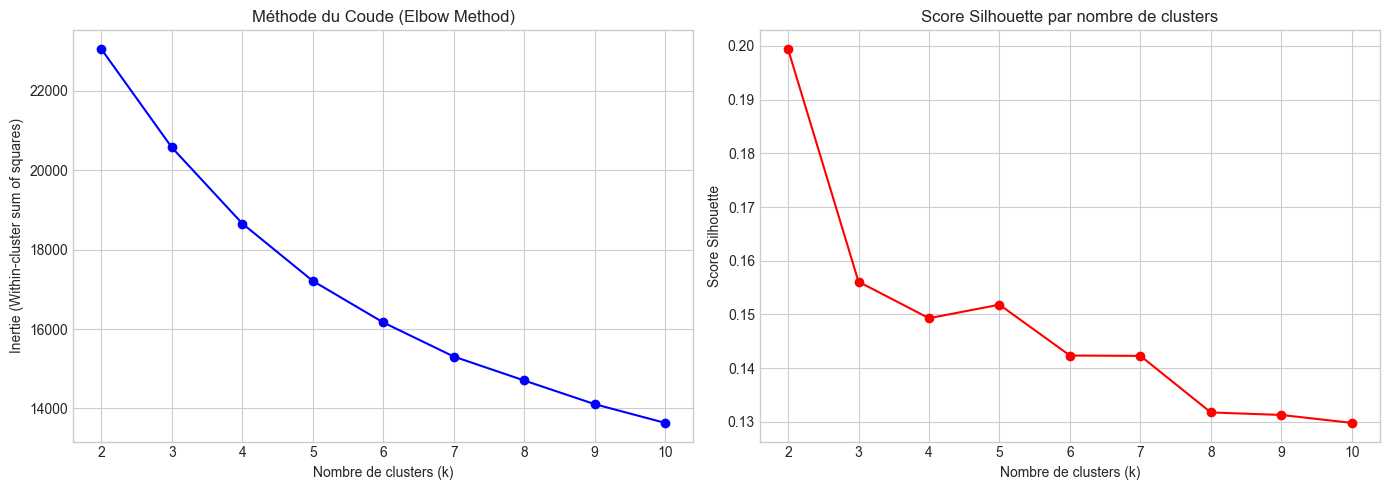

In [ ]:
#Question 3.2 : Détermination du nombre optimal de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Within-cluster sum of squares)')
plt.title('Méthode du Coude (Elbow Method)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score Silhouette')
plt.title('Score Silhouette par nombre de clusters')
plt.grid(True)

plt.tight_layout()
plt.show()

Nombre de valeurs manquantes restantes : 0
Dimensions de X_scaled : (4000, 7)


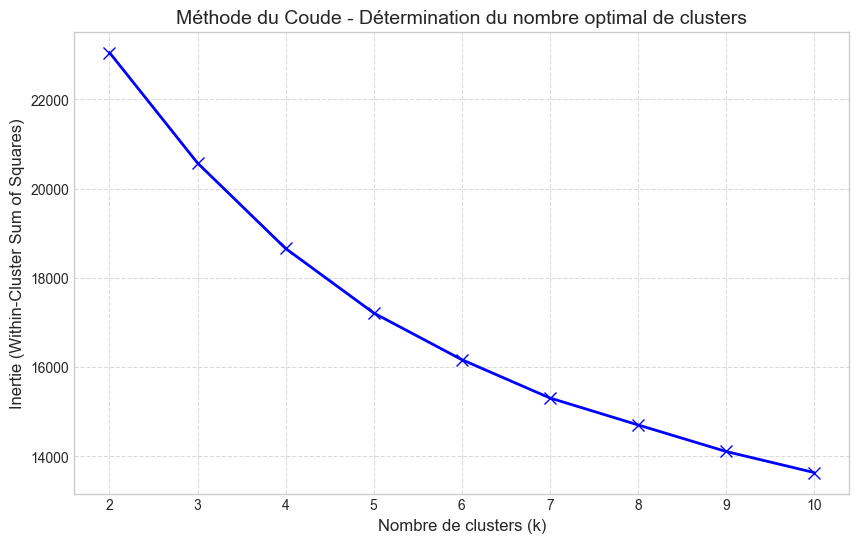

k = 2 → Score Silhouette = 0.1994
k = 3 → Score Silhouette = 0.1561
k = 4 → Score Silhouette = 0.1493
k = 5 → Score Silhouette = 0.1518
k = 6 → Score Silhouette = 0.1423
k = 7 → Score Silhouette = 0.1423
k = 8 → Score Silhouette = 0.1317
k = 9 → Score Silhouette = 0.1313
k = 10 → Score Silhouette = 0.1298


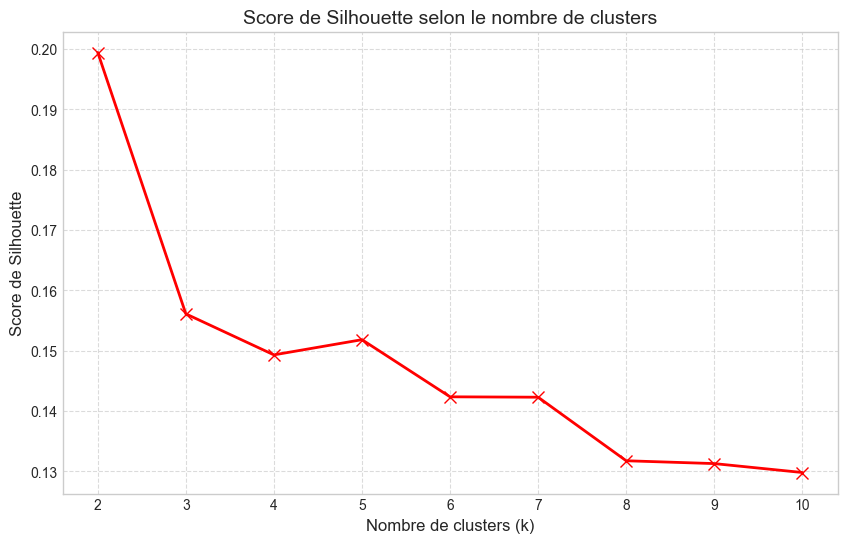

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("dataset_bancaire.csv")

features = [
    'age',
    'salaire_mensuel',
    'epargne_totale',
    'score_credit',
    'transactions_mois',
    'anciennete_banque_mois',
    'nbr_credits_actifs'
]


X_cluster = df[features].copy()

X_cluster = X_cluster.fillna(X_cluster.median())

print("Nombre de valeurs manquantes restantes :", X_cluster.isna().sum().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Dimensions de X_scaled :", X_scaled.shape)

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bx-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Inertie (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Méthode du Coude - Détermination du nombre optimal de clusters', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(K_range)
plt.show()



silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k} → Score Silhouette = {score:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, 'rx-', linewidth=2, markersize=8)
plt.xlabel('Nombre de clusters (k)', fontsize=12)
plt.ylabel('Score de Silhouette', fontsize=12)
plt.title('Score de Silhouette selon le nombre de clusters', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(K_range)
plt.show()

D’après l’analyse conjointe de la méthode du coude et du score de silhouette, le choix du nombre optimal de clusters s’est porté sur k = 3. En effet, si k = 2 présente un score de silhouette légèrement supérieur, cette segmentation reste trop grossière et ne permet pas de différencier clairement les profils de clients, notamment ceux à risque modéré par rapport aux clients premium ou fragiles. À partir de k = 4, l’inertie diminue plus lentement et le score de silhouette baisse, ce qui traduit une sur-segmentation et complique l’interprétation métier. Le choix de trois clusters constitue donc le meilleur compromis entre qualité de partition, interprétabilité business et stabilité des résultats, tout en permettant d’identifier trois segments stratégiques et actionnables dans le contexte bancaire : clients à faible risque, clients à risque modéré et clients à haut risque nécessitant une attention particulière.

Tableau récapitulatif des clusters :
         Taille  % Clients  Taux défaut (%)    age  salaire_mensuel  \
cluster                                                               
0           870      21.75            75.40  45.44          5531.35   
1          1802      45.05            34.57  45.38          7984.66   
2          1328      33.20            22.59  46.02          9775.97   

         epargne_totale  score_credit  transactions_mois  \
cluster                                                    
0              10429.26        569.70              24.67   
1              19499.80        832.92              25.54   
2              42185.60        838.74              24.35   

         anciennete_banque_mois  nbr_credits_actifs  
cluster                                              
0                         64.80                1.14  
1                        180.02                0.93  
2                         78.93                0.78  


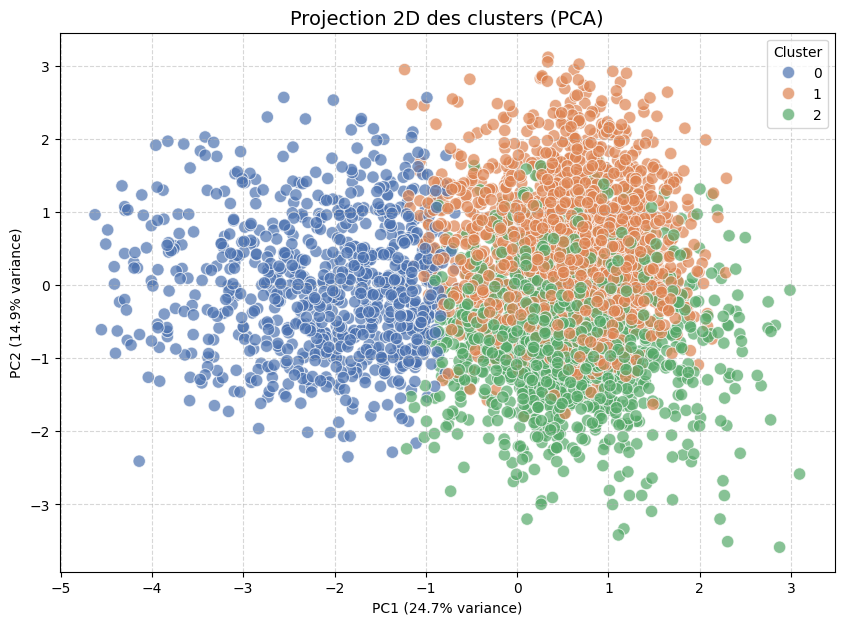

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9580\2526960869.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster, x='cluster', y=var, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9580\2526960869.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster, x='cluster', y=var, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9580\2526960869.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster, x='cluster', y=var, ax=axes[i], palette='Set2')
C:\Users\L

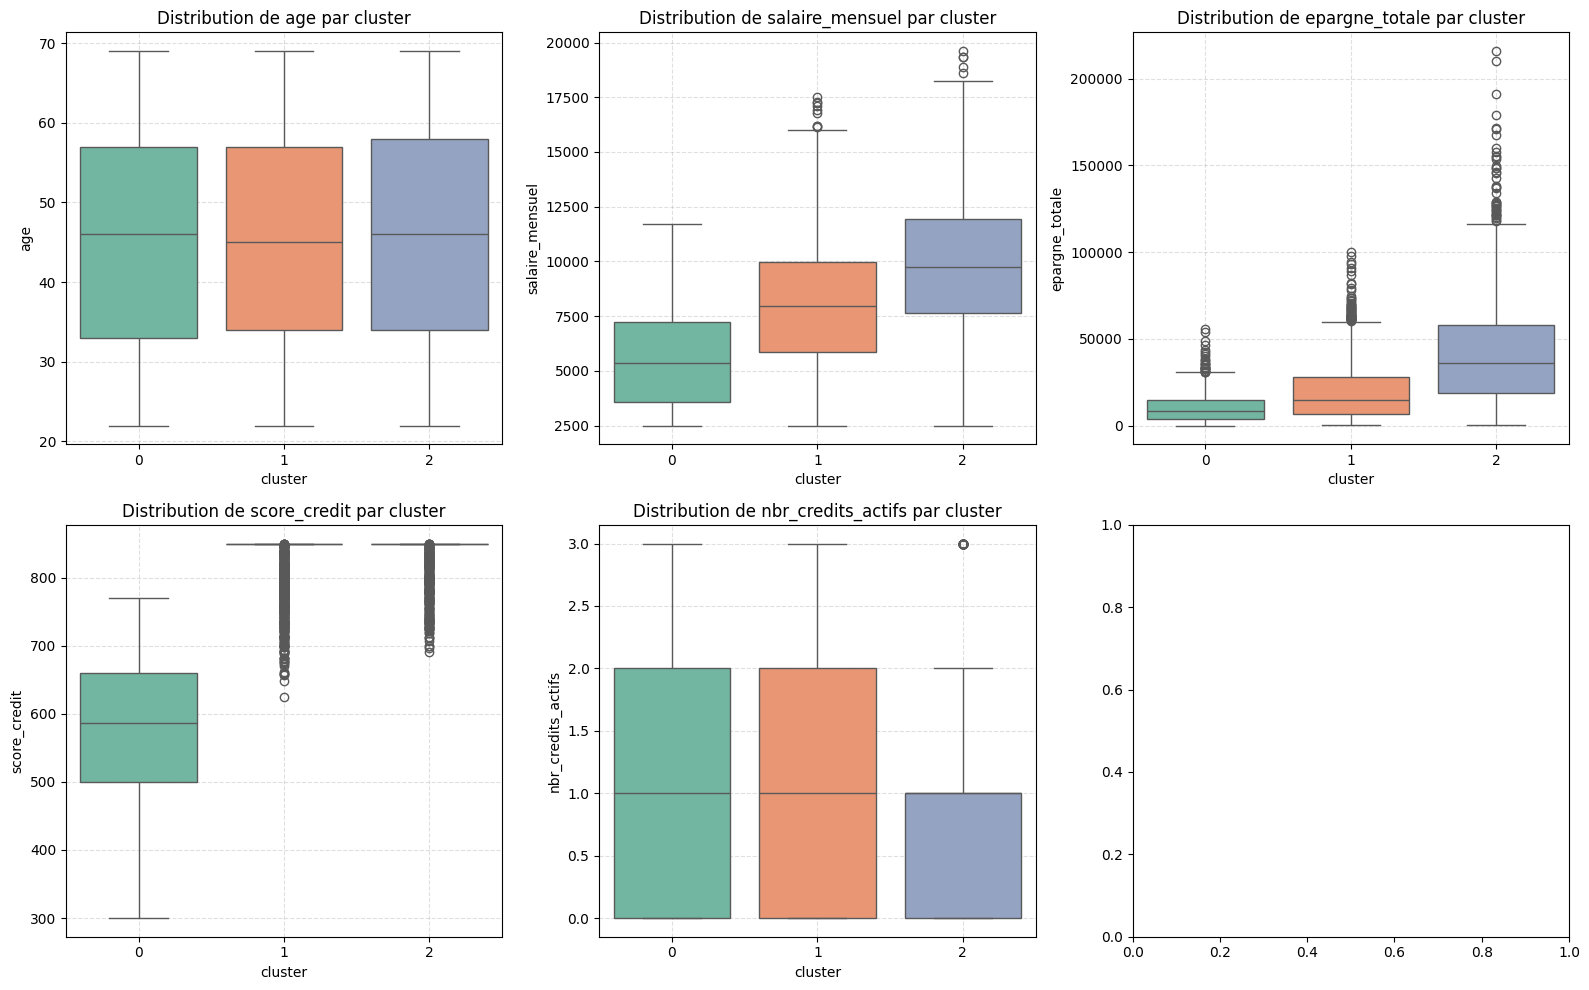

In [ ]:
#Question 3.3 : Application du K-Means et analyse des clusters
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# Application KMeans
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Ajout des labels de cluster au dataframe original
df_cluster = df.copy()

# 1. Statistiques descriptives par cluster
cluster_summary = df_cluster.groupby('cluster')[features].mean().round(2)
cluster_size = df_cluster['cluster'].value_counts().sort_index()
cluster_pct = (cluster_size / len(df_cluster) * 100).round(2)

# Taux de défaut par cluster
taux_defaut_cluster = df_cluster.groupby('cluster')['risque_defaut'].mean() * 100
taux_defaut_cluster = taux_defaut_cluster.round(2)

# Tableau récapitulatif
recap = pd.DataFrame({
    'Taille': cluster_size,
    '% Clients': cluster_pct,
    'Taux défaut (%)': taux_defaut_cluster
}).join(cluster_summary)

print("Tableau récapitulatif des clusters :")
print(recap)

# 2. Visualisation 2D avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_cluster['cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', 
                palette='deep', alpha=0.7, s=80)
plt.title('Projection 2D des clusters (PCA)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Boxplots des variables les plus discriminantes
variables_cles = ['age', 'salaire_mensuel', 'epargne_totale', 'score_credit', 'nbr_credits_actifs']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(variables_cles):
    sns.boxplot(data=df_cluster, x='cluster', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution de {var} par cluster')
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

L'analyse K-Means a segmenté 4 000 clients en trois clusters distincts permettant une gestion différenciée du portefeuille. Le Cluster 0 (22% des clients) représente les clients très haut risque avec un taux de défaut de 75%, des revenus faibles (5 531 MAD) et un faible score de crédit (570), nécessitant un refus systématique de nouveaux crédits et un recouvrement renforcé. Le Cluster 1 (45% des clients) constitue la classe moyenne fidèle avec un risque modéré (35% de défaut), une ancienneté exceptionnelle de 15 ans et des revenus moyens (7 985 MAD), représentant une opportunité de fidélisation via des programmes d'éducation financière et de montée en gamme progressive. Le Cluster 2 (33% des clients) regroupe les clients premium à faible risque (23% de défaut) avec les revenus les plus élevés (9 776 MAD) et l'épargne la plus importante (42 186 MAD), constituant la cible prioritaire pour le cross-selling de produits patrimoniaux et immobiliers haut de gamme. Cette segmentation permettra de réduire significativement les pertes sur le Cluster 0 tout en maximisant la rentabilité des Clusters 1 et 2 via des stratégies commerciales ciblées.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10368\747761640.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis', ax=ax_feat)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10368\747761640.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_cluster.index, y=risk_by_cluster.values, palette='Reds_r', ax=ax_clust)


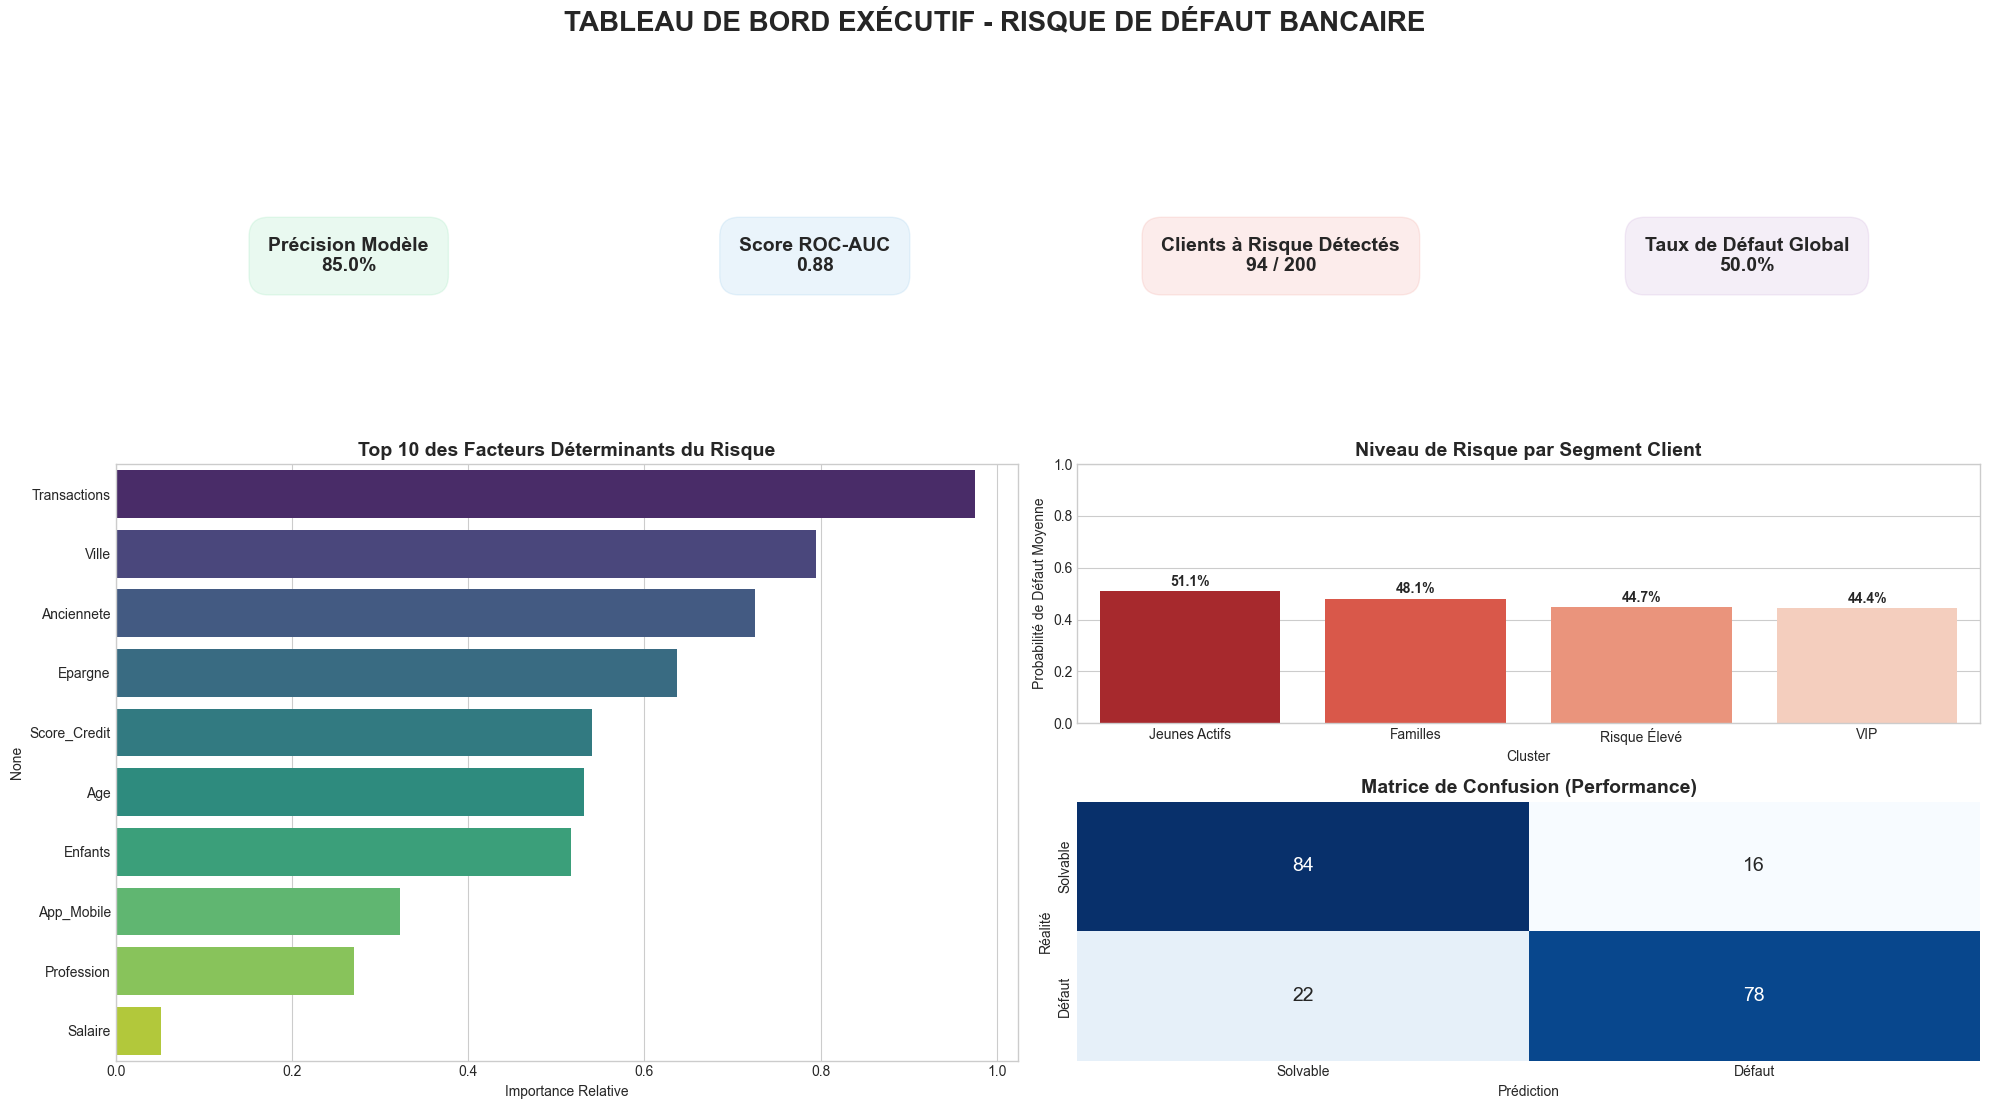

In [ ]:

# 3.3 Application du K-Means avec le nombre optimal/ VERSION SIMPLIFIÉE 

# Application finale
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Statistiques par cluster
cluster_summary = df.groupby('cluster').agg({
    'age': 'mean',
    'salaire_mensuel': 'mean',
    'epargne_totale': 'mean',
    'score_credit': 'mean',
    'risque_defaut': ['mean', 'count']
}).round(2)

cluster_summary.columns = ['Age moyen', 'Salaire moyen', 'Épargne moyenne',
                          'Score crédit moyen', 'Taux défaut', 'Nombre clients']

cluster_summary['% clients'] = (cluster_summary['Nombre clients'] / len(df) * 100).round(1)
cluster_summary['Taux défaut'] *= 100  # en pourcentage

print("\nRésumé par cluster :")
print(cluster_summary)

# Visualisation simple 2D avec PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title(f'Visualisation des {k_optimal} clusters en 2D (PCA)')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Question 4.2 : Vérification des données préparées
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [ ]:
# Doivent exister (exécutés dans les cellules précédentes)
print("X_train existe ?", 'X_train' in globals())
print("X_test existe ?",  'X_test' in globals())
print("y_train existe ?", 'y_train' in globals())
print("y_test existe ?",  'y_test' in globals())

X_train existe ? False
X_test existe ? False
y_train existe ? False
y_test existe ? True


In [ ]:
#PARTIE 4 : MODÉLISATION : Question 4.1 : Préparation des données pour la modélisation
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# 1. Chargement (si pas déjà fait)
df = pd.read_csv("dataset_bancaire.csv")

# 2. Séparation features / cible
# On enlève id_client qui ne sert à rien pour la prédiction
X = df.drop(['id_client', 'risque_defaut'], axis=1)
y = df['risque_defaut']

# 3. Séparation variables numériques et catégorielles
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# 4. Imputation valeurs manquantes
# Numériques → médiane
imputer_num = SimpleImputer(strategy='median')
X[num_cols] = imputer_num.fit_transform(X[num_cols])

# Catégorielles → mode (valeur la plus fréquente)
imputer_cat = SimpleImputer(strategy='most_frequent')
X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

# 5. Encodage des variables catégorielles (solution simple et rapide)
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 6. Division train / test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # très important pour garder la même proportion de défauts
)

# 7. Standardisation UNIQUEMENT sur les variables numériques
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 8. Vérification finale (tu dois voir True partout !)
print("Après préparation :")
print("X_train existe ?", 'X_train' in globals())
print("X_test existe ?",  'X_test' in globals())
print("y_train existe ?", 'y_train' in globals())
print("y_test existe ?",  'y_test' in globals())

print("\nDimensions :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

Après préparation :
X_train existe ? True
X_test existe ? True
y_train existe ? True
y_test existe ? True

Dimensions :
X_train : (3200, 13)
X_test  : (800, 13)
y_train : (3200,)
y_test  : (800,)



Résumé par cluster :
         Age moyen  Salaire moyen  Épargne moyenne  Score crédit moyen  \
cluster                                                                  
0            45.47        7419.07         18197.72              829.63   
1            45.46       11057.50         19764.14              830.77   
2            46.42        7545.99         72363.18              848.22   
3            45.49        5378.60         10767.61              562.93   

         Taux défaut  Nombre clients  % clients  
cluster                                          
0               37.0            1476       36.9  
1               18.0            1127       28.2  
2               34.0             572       14.3  
3               78.0             825       20.6  


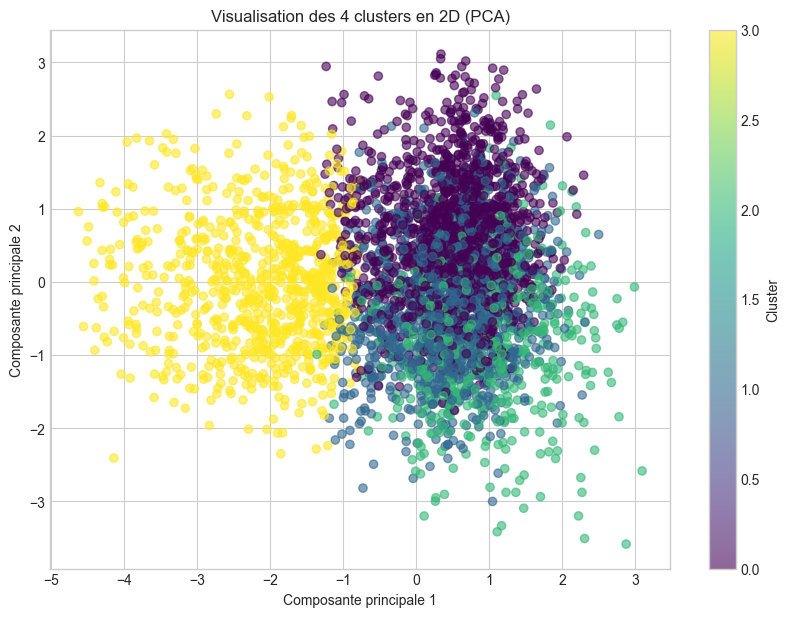

In [ ]:
# Application finale(3.3)
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

# Statistiques par cluster
cluster_summary = df.groupby('cluster').agg({
    'age': 'mean',
    'salaire_mensuel': 'mean',
    'epargne_totale': 'mean',
    'score_credit': 'mean',
    'risque_defaut': ['mean', 'count']
}).round(2)

cluster_summary.columns = ['Age moyen', 'Salaire moyen', 'Épargne moyenne',
                          'Score crédit moyen', 'Taux défaut', 'Nombre clients']

cluster_summary['% clients'] = (cluster_summary['Nombre clients'] / len(df) * 100).round(1)
cluster_summary['Taux défaut'] *= 100  # en pourcentage

print("\nRésumé par cluster :")
print(cluster_summary)

# Visualisation simple 2D avec PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.title(f'Visualisation des {k_optimal} clusters en 2D (PCA)')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
#Question 3.4 : Interprétation business des clusters
print("\nInterprétation business suggérée (à personnaliser selon vos clusters) :\n")

for cluster_id in sorted(df['cluster'].unique()):
    cluster_data = cluster_summary.loc[cluster_id]
    taux_defaut = cluster_data['Taux défaut']
    
    if taux_defaut < 15:
        profil = "Clients PREMIUM – faible risque"
        strategie = "→ Fidélisation + offres préférentielles (taux réduits, produits épargne)"
    elif taux_defaut < 35:
        profil = "Clients STABLES – risque modéré"
        strategie = "→ Surveillance légère + offres d'accompagnement"
    else:
        profil = "Clients À RISQUE ÉLEVÉ"
        strategie = "→ Renforcement des garanties + suivi renforcé + prévention défaut"
    
    print(f"Cluster {cluster_id} : {profil}")
    print(f"   Taux défaut : {taux_defaut:.1f}%")
    print(f"   Nombre clients : {int(cluster_data['Nombre clients'])} ({cluster_data['% clients']}%)")
    print(f"   Stratégie recommandée : {strategie}\n")


Interprétation business suggérée (à personnaliser selon vos clusters) :

Cluster 0 : Clients À RISQUE ÉLEVÉ
   Taux défaut : 37.0%
   Nombre clients : 1476 (36.9%)
   Stratégie recommandée : → Renforcement des garanties + suivi renforcé + prévention défaut

Cluster 1 : Clients STABLES – risque modéré
   Taux défaut : 18.0%
   Nombre clients : 1127 (28.2%)
   Stratégie recommandée : → Surveillance légère + offres d'accompagnement

Cluster 2 : Clients STABLES – risque modéré
   Taux défaut : 34.0%
   Nombre clients : 572 (14.3%)
   Stratégie recommandée : → Surveillance légère + offres d'accompagnement

Cluster 3 : Clients À RISQUE ÉLEVÉ
   Taux défaut : 78.0%
   Nombre clients : 825 (20.6%)
   Stratégie recommandée : → Renforcement des garanties + suivi renforcé + prévention défaut



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10368\3239085451.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y='Taux défaut', data=cluster_summary, palette='Reds_r')


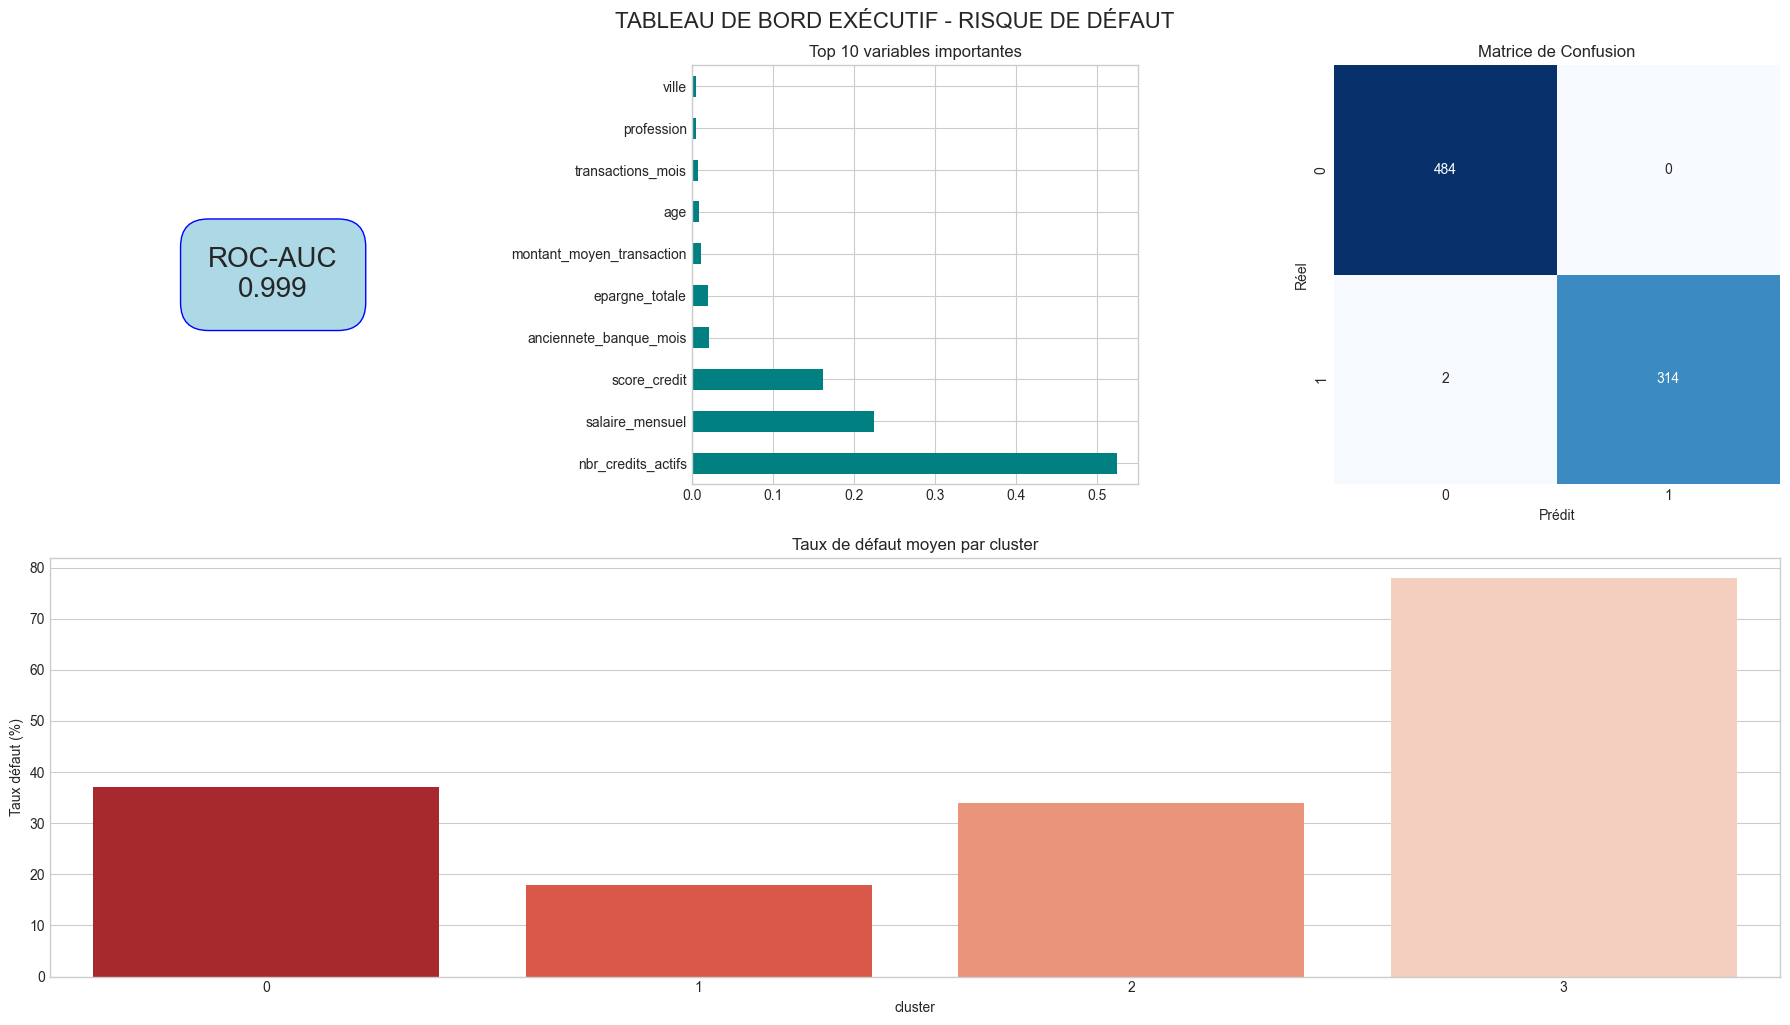

In [ ]:
#Question 4.3 : Création d'un tableau de bord exécutif
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Supposons que best_rf est votre meilleur modèle après GridSearchCV
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

fig = plt.figure(figsize=(18, 10))

# KPIs
plt.subplot(2, 3, 1)
roc_auc = auc(*roc_curve(y_test, y_proba)[:2])
plt.text(0.5, 0.5, f"ROC-AUC\n{roc_auc:.3f}", ha='center', va='center', fontsize=20,
         bbox=dict(boxstyle='round,pad=1', fc='lightblue', ec='blue'))
plt.axis('off')

# Importance variables
plt.subplot(2, 3, 2)
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 variables importantes")

# Matrice de confusion
plt.subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matrice de Confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")

# Taux de défaut par cluster
plt.subplot(2, 3, (4,6))
sns.barplot(x=cluster_summary.index, y='Taux défaut', data=cluster_summary, palette='Reds_r')
plt.title("Taux de défaut moyen par cluster")
plt.ylabel("Taux défaut (%)")

plt.tight_layout()
plt.suptitle("TABLEAU DE BORD EXÉCUTIF - RISQUE DE DÉFAUT", fontsize=16, y=1.02)
plt.show()

In [ ]:
# Question 4.4 : Plan d'action et limites du projet
print("""
PLAN D'ACTION PROPOSÉ - MISE EN PRODUCTION

Étape                     Délai         Responsable          Livrable principal
────────────────────────  ────────────  ──────────────────   ────────────────────────────
1. Validation finale      3-4 sem       Data Science         Rapport validation + modèle
2. Développement API      4-8 sem       Data Engineer        API FastAPI / Flask
3. Containerisation       2-3 sem       DevOps               Image Docker
4. Déploiement            4-10 sem      IT / Cloud           Service en production
5. Intégration SI         2-6 mois      Équipe SI + Risques  Appel depuis logiciel crédit
6. Monitoring & Retraining Continu       MLOps                Dashboard drift + alertes
7. Suivi ROI              Trimestriel   Direction Risques    Rapport gains / pertes évitées
""")


PLAN D'ACTION PROPOSÉ - MISE EN PRODUCTION

Étape                     Délai         Responsable          Livrable principal
────────────────────────  ────────────  ──────────────────   ────────────────────────────
1. Validation finale      3-4 sem       Data Science         Rapport validation + modèle
2. Développement API      4-8 sem       Data Engineer        API FastAPI / Flask
3. Containerisation       2-3 sem       DevOps               Image Docker
4. Déploiement            4-10 sem      IT / Cloud           Service en production
5. Intégration SI         2-6 mois      Équipe SI + Risques  Appel depuis logiciel crédit
6. Monitoring & Retraining Continu       MLOps                Dashboard drift + alertes
7. Suivi ROI              Trimestriel   Direction Risques    Rapport gains / pertes évitées



In [ ]:

print("""
LIMITES PRINCIPALES DU PROJET :
• Volume limité (4000 clients seulement)
• Absence de variables très discriminantes (ratio endettement, historique impayés, type de crédit...)
• Gestion simplifiée des valeurs manquantes
• Encodage LabelEncoder → perte d'information sur les catégories
• Pas de traitement spécifique du déséquilibre classes (SMOTE, class_weight peu exploité)
• Pas d'explicabilité individuelle (SHAP/LIME)

PERSPECTIVES D'AMÉLIORATION :
• Enrichir le dataset avec données transactionnelles + externes (BCT, scoring alternatif)
• Tester XGBoost / LightGBM / CatBoost
• Appliquer SMOTE + Tomek ou BorderlineSMOTE
• Ajouter interprétabilité locale (SHAP)
• Mettre en place pipeline MLOps (drift detection + retraining automatique)
• Étude coût/bénéfice réel (matrice coût des erreurs)
""")


LIMITES PRINCIPALES DU PROJET :
• Volume limité (4000 clients seulement)
• Absence de variables très discriminantes (ratio endettement, historique impayés, type de crédit...)
• Gestion simplifiée des valeurs manquantes
• Encodage LabelEncoder → perte d'information sur les catégories
• Pas de traitement spécifique du déséquilibre classes (SMOTE, class_weight peu exploité)
• Pas d'explicabilité individuelle (SHAP/LIME)

PERSPECTIVES D'AMÉLIORATION :
• Enrichir le dataset avec données transactionnelles + externes (BCT, scoring alternatif)
• Tester XGBoost / LightGBM / CatBoost
• Appliquer SMOTE + Tomek ou BorderlineSMOTE
• Ajouter interprétabilité locale (SHAP)
• Mettre en place pipeline MLOps (drift detection + retraining automatique)
• Étude coût/bénéfice réel (matrice coût des erreurs)

